# 05 · 전체 모델 비교와 논문용 결과 정리

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lab-axis/Wind-Power-Forecasting/blob/main/notebooks/05_comparison_and_research_limits.ipynb)

모든 표·그림은 동일한 새 실행의 검증된 저장 예측을 사용합니다. 본문 배치는 표준 모델 중심으로 간추리되 전체 15개 모델 결과와 확률 비교를 남깁니다. 표시 모델을 간추리는 것은 편집 결정이며 불리한 결과를 제거하거나 실험 전에 정한 것처럼 소급하는 절차가 아닙니다.

In [1]:
from pathlib import Path
import os, sys

# Google Colab 자동 감지 및 환경 설정
if 'google.colab' in sys.modules or (os.path.exists('/content') and not (Path.cwd() / "configs/base_config.yaml").exists()):
    repo_dir = Path('/content/Wind-Power-Forecasting')
    if not repo_dir.exists():
        print("Google Colab 환경 감지: Wind-Power-Forecasting 저장소를 클론합니다...")
        import subprocess
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/lab-axis/Wind-Power-Forecasting.git", str(repo_dir)], check=True)
        print("필수 의존 패키지를 설치합니다 (colab/requirements-colab.txt)...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(repo_dir / "colab/requirements-colab.txt")], check=True)
    os.chdir(repo_dir)
    sys.path.insert(0, str(repo_dir))
    try:
        get_ipython().run_line_magic('cd', str(repo_dir))
    except Exception:
        pass

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "configs/base_config.yaml").exists())
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
runtime = ROOT / ".experiment_archive/python_runtime"
if runtime.exists(): sys.path.insert(0, str(runtime))
from IPython.display import display
from src.workflows import research as wf
%matplotlib inline

In [2]:
wf.run_status()

,run_id,status,models,local_artifacts_available,model_horizon_seed_combinations,metric_rows,seeds,horizons,test_role,data_sha256
0,all_baselines_20261005T143556+0900,complete,15,True,234,468,"[42, 2026, 3407]","[1, 3, 6, 9, 12, 24]",development_benchmark_previously_consulted,01861a5a18cac3731f4238d9307d03e2bb29d9c3aa11e8...


## 1. 공통 시점 확인

모든 모델·시드의 target_time, issue_time, y_true를 대조합니다. ARIMA·Persistence에도 동일한 공통 표본을 적용합니다. 데이터 누락이나 horizon 차이를 행 순서만으로 맞추지 않습니다.

In [3]:
wf.verify_common_samples()

,split,horizon_hours,model_seed_combinations,common_count
0,validation,1,39,4249
1,validation,3,39,4247
2,validation,6,39,4244
3,validation,9,39,4241
4,validation,12,39,4238
5,validation,24,39,4226
6,test,1,39,8736
7,test,3,39,8734
8,test,6,39,8731
9,test,9,39,8728


## 2. 본문 표: 5개 모델, 대표 3개 시계

**EMFN + Naive Persistence + ARIMA + LSTM + 일반 LightGBM(24h)**. LightGBM 계열은 본문에서 한 모델만 사용합니다. CRPS/Brier/RMSE/MAE/AUPRC를 나열하고 +1h/+6h/+24h를 표로, 전체 시계를 곡선으로 제시합니다. N/A는 점출력 모델에 예측 확률이 없다는 뜻입니다.

In [4]:
wf.display_scores(models=wf.MAIN, horizons=(1,6,24))

,model,horizon_hours,n_fits,crps,zero_brier,rmse,mae,zero_auprc
0,EMFN (Proposed),1,3,0.5802 ± 0.0058,0.0693 ± 0.0017,1.2879 ± 0.0155,0.8003 ± 0.0099,0.7516 ± 0.0028
1,Naive Persistence,1,1,0.8602,N/A,1.4337,0.8602,N/A
2,ARIMA,1,1,0.6689,0.1017,1.4261,0.8369,0.6213
3,LSTM (+Weather),1,3,0.7899 ± 0.0147,N/A,1.2806 ± 0.0244,0.7900 ± 0.0147,N/A
4,LightGBM (24h matched),1,3,0.8209 ± 0.0000,N/A,1.2867 ± 0.0000,0.8209 ± 0.0000,N/A
5,EMFN (Proposed),6,3,1.4529 ± 0.0329,0.1144 ± 0.0006,3.1678 ± 0.0647,2.0239 ± 0.0378,0.4343 ± 0.0043
6,Naive Persistence,6,1,2.3944,N/A,3.8407,2.3944,N/A
7,ARIMA,6,1,1.7710,0.1218,3.5683,2.4608,0.4102
8,LSTM (+Weather),6,3,2.0561 ± 0.0100,N/A,3.3406 ± 0.0387,2.0561 ± 0.0099,N/A
9,LightGBM (24h matched),6,3,2.1528 ± 0.0000,N/A,3.0982 ± 0.0000,2.1528 ± 0.0000,N/A


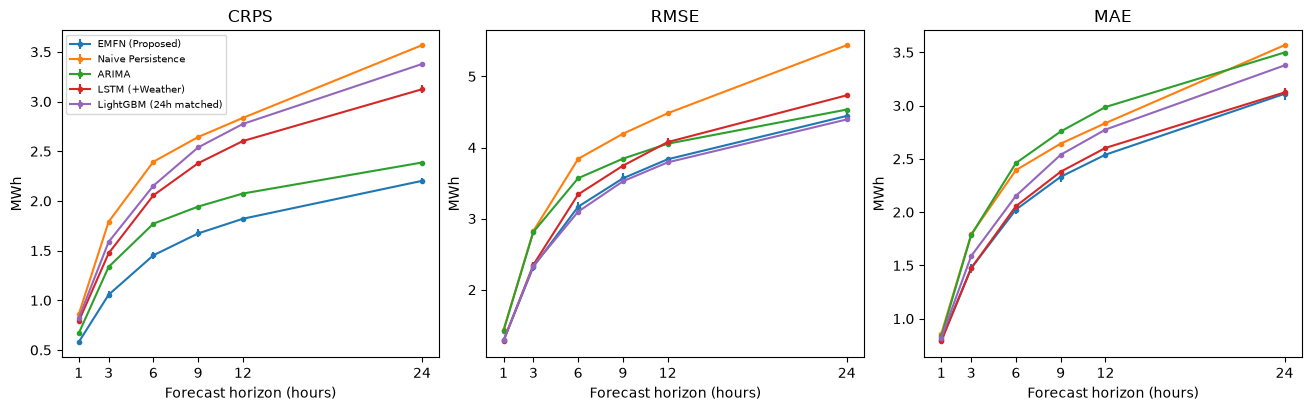

In [5]:
wf.plot_horizons(models=wf.MAIN);

## 3. 확률 베이스라인과 보정 한계

ARIMA, 분위수 LightGBM, 허들 분위수 LightGBM을 비교합니다. 기존 분위수·허들 모델의 수치가 유리하거나 불리해도 보존합니다. EMFN 대 점예측 모델의 CRPS 비교만으로 확률 모델 일반에 대한 우월성을 주장하지 않습니다. 명목 구간 포함률·구간 폭과 Brier를 같이 해석합니다. 점질량이 있는 중앙 예측구간은 보정된 분포에서도 포함률이 정확히 90%가 아닐 수 있습니다.

In [6]:
probabilistic = ["EMFN (Proposed)", "ARIMA", "Quantile LightGBM (24h matched)", "Hurdle Quantile LightGBM (24h matched)"]
wf.display_scores(models=probabilistic, horizons=None)

,model,horizon_hours,n_fits,crps,zero_brier,rmse,mae,zero_auprc
0,EMFN (Proposed),1,3,0.5802 ± 0.0058,0.0693 ± 0.0017,1.2879 ± 0.0155,0.8003 ± 0.0099,0.7516 ± 0.0028
1,ARIMA,1,1,0.6689,0.1017,1.4261,0.8369,0.6213
2,Quantile LightGBM (24h matched),1,3,0.5960 ± 0.0000,0.1179 ± 0.0000,1.3950 ± 0.0000,0.8051 ± 0.0000,0.5986 ± 0.0000
3,Hurdle Quantile LightGBM (24h matched),1,3,0.5813 ± 0.0000,0.0643 ± 0.0000,1.3489 ± 0.0000,0.7921 ± 0.0000,0.7585 ± 0.0000
4,EMFN (Proposed),3,3,1.0563 ± 0.0363,0.0963 ± 0.0027,2.3238 ± 0.0652,1.4748 ± 0.0422,0.5601 ± 0.0114
5,ARIMA,3,1,1.3362,0.1276,2.8134,1.7853,0.4755
6,Quantile LightGBM (24h matched),3,3,1.1104 ± 0.0000,0.1204 ± 0.0000,2.5131 ± 0.0000,1.4976 ± 0.0000,0.4632 ± 0.0000
7,Hurdle Quantile LightGBM (24h matched),3,3,1.0878 ± 0.0000,0.0932 ± 0.0000,2.4442 ± 0.0000,1.4859 ± 0.0000,0.5554 ± 0.0000
8,EMFN (Proposed),6,3,1.4529 ± 0.0329,0.1144 ± 0.0006,3.1678 ± 0.0647,2.0239 ± 0.0378,0.4343 ± 0.0043
9,ARIMA,6,1,1.7710,0.1218,3.5683,2.4608,0.4102


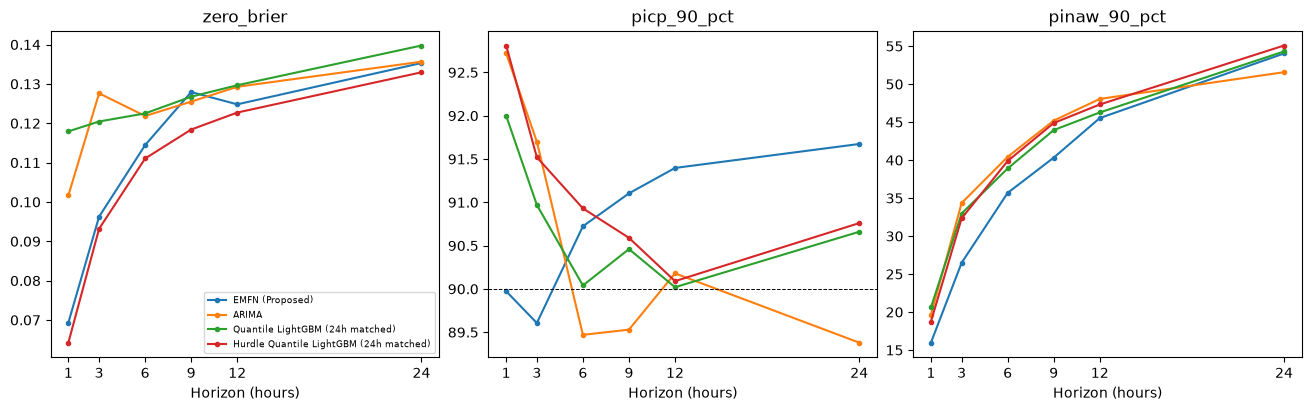

In [7]:
wf.plot_probability_comparison();

## 4. 검증 구간 결과와 전체 지표

검증 결과는 모델 선택에 사용한 구간의 점수이지 독립 성능이 아닙니다. 아래 변수에는 본문에서 생략한 모델·시계·전체 계산 지표가 모두 남습니다. raw 물리 위반율은 clipping 전 출력, 점오차는 bounded 출력에 대한 값입니다. 0에 가까운 발전량 때문에 MAPE가 불안정할 수 있으므로 보조 진단으로만 봅니다.

In [8]:
wf.display_scores(split="validation", models=wf.MAIN, horizons=(1,6,24))

,model,horizon_hours,n_fits,crps,zero_brier,rmse,mae,zero_auprc
0,EMFN (Proposed),1,3,0.5206 ± 0.0036,0.0728 ± 0.0008,1.1601 ± 0.0132,0.7205 ± 0.0063,0.8164 ± 0.0029
1,Naive Persistence,1,1,0.8028,N/A,1.3144,0.8028,N/A
2,ARIMA,1,1,0.6262,0.1107,1.3258,0.7783,0.7137
3,LSTM (+Weather),1,3,0.7358 ± 0.0076,N/A,1.1924 ± 0.0192,0.7359 ± 0.0076,N/A
4,LightGBM (24h matched),1,3,0.7723 ± 0.0000,N/A,1.1945 ± 0.0000,0.7723 ± 0.0000,N/A
5,EMFN (Proposed),6,3,1.1856 ± 0.0114,0.1204 ± 0.0015,2.6066 ± 0.0334,1.6491 ± 0.0261,0.5690 ± 0.0106
6,Naive Persistence,6,1,2.0049,N/A,3.2818,2.0049,N/A
7,ARIMA,6,1,1.5510,0.1396,3.1262,2.2052,0.5231
8,LSTM (+Weather),6,3,1.7597 ± 0.0273,N/A,2.8327 ± 0.0459,1.7597 ± 0.0273,N/A
9,LightGBM (24h matched),6,3,1.8355 ± 0.0000,N/A,2.6041 ± 0.0000,1.8355 ± 0.0000,N/A


In [9]:
full_results = wf.metrics_table(full=True, horizons=None)
display(full_results)
print("Full metric rows:", len(full_results))

,model,seed,horizon_hours,split,selection_basis,mae,rmse,mse,nmae_pct,nrmse_pct,...,crps,zero_point_f1_mean,zero_point_balanced_acc_mean,zero_brier,zero_auprc,zero_auroc,zero_ece,picp_90_pct,pinaw_90_pct,winkler_score_90
1,Naive Persistence,NaN,1,test,fixed_rule_no_selection,0.8602,1.4337,2.0555,4.0963,6.8272,...,0.860221,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Diurnal Persistence,NaN,1,test,fixed_rule_no_selection,3.5634,5.4338,29.5260,16.9686,25.8752,...,3.563410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Naive Persistence,NaN,3,test,fixed_rule_no_selection,1.7905,2.8251,7.9814,8.5263,13.4530,...,1.790521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Diurnal Persistence,NaN,3,test,fixed_rule_no_selection,3.5636,5.4342,29.5310,16.9695,25.8773,...,3.563597,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Naive Persistence,NaN,6,test,fixed_rule_no_selection,2.3944,3.8407,14.7507,11.4017,18.2889,...,2.394366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
459,Transformer (+Weather),3407.0,24,test,validation_crps,3.1064,4.8002,23.0418,14.7922,22.8580,...,3.106366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
461,LightGBM (24h matched),3407.0,24,test,validation_crps,3.3772,4.3946,19.3125,16.0818,20.9267,...,3.377186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
463,Quantile LightGBM (24h matched),3407.0,24,test,validation_crps,3.0006,4.3667,19.0682,16.0353,20.7939,...,2.162791,0.0,0.5,0.139754,0.209070,0.595393,0.074659,90.66,54.30,16.8024
465,Hurdle Quantile LightGBM (24h matched),3407.0,24,test,validation_crps,3.0170,4.3817,19.1997,16.1124,20.8654,...,2.175792,0.0,0.5,0.132950,0.242116,0.651681,0.021330,90.76,55.08,16.4622


Full metric rows: 234


## 5. 논문에서 남겨야 할 한계와 다음 단계

1. 2025년은 반복 열람한 개발 벤치마크. 2026년은 기술통계 열람 이력이 있으나 성능 선택에는 미사용이며 아직 평가하지 않았습니다.
2. 단위·1시간 집계 경계·계량 경계·관측 전달 지연의 기관 확인이 남습니다. 관측소 풍속은 터빈 허브 높이 풍속과 같다고 가정하지 않습니다.
3. 서로 다른 입력 예산(24h/168h/history/calendar), 학습 손실·예산을 명시합니다. Prophet의 train-only 달력 예측은 최근 상태를 반영하는 rolling-origin 모델과 정보 사용이 다릅니다.
4. 시드 SD는 학습 변동입니다. 기존 실행의 paired block 구간을 새 실행의 검정 결과로 재사용하지 않습니다.
5. 다중 시드 구조 어블레이션, 기상 변수군 기여, 최종 설계 고정 후 후속 기간 평가가 남습니다. 예측 정보 기여를 인과 효과로 바꾸어 주장하지 않습니다.

재현 추적: `reports/all_baselines_manifest.json` → `models/runs/<run_id>/source.zip`, 가중치, epoch 이력, validation/test 예측 → `reports/all_baselines_validation.json` → 최신 CSV. 모든 상세 로직은 `.py`에서 관리하며 노트북에는 중복 학습 구현을 두지 않습니다.